In [14]:
from fer import FER
import cv2
import time
import numpy as np
from collections import defaultdict, deque
import csv
from datetime import datetime
import os

os.makedirs("logs", exist_ok=True)
print("✅ All imports successful")

✅ All imports successful


In [15]:
EMOTION_COLORS = {
    'happy':    (50,  205, 50),
    'sad':      (220, 100, 30),
    'angry':    (30,  30,  220),
    'neutral':  (180, 180, 180),
    'surprise': (30,  200, 220),
    'fear':     (180, 60,  220),
    'disgust':  (60,  180, 30),
}

# Tunable settings
DETECT_EVERY_N_FRAMES = 2
SMOOTH_WINDOW         = 5
FRAME_SCALE           = 0.6

print("✅ Config ready")

✅ Config ready


In [16]:
def draw_face(frame, box, emotion, confidence, all_emotions):
    x, y, w, h = box
    color = EMOTION_COLORS.get(emotion, (255, 255, 255))

    # Clamp box to frame boundaries
    fh, fw = frame.shape[:2]
    x, y   = max(0,x), max(0,y)
    w, h   = min(w, fw-x), min(h, fh-y)

    # Bounding box
    cv2.rectangle(frame, (x,y), (x+w, y+h), color, 2)

    # Label background + text
    label = f"{emotion.upper()}  {confidence*100:.1f}%"
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(frame, (x, y-th-12), (x+tw+8, y), color, -1)
    cv2.putText(frame, label, (x+4, y-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

    # Confidence bar below face
    bar_w = int(w * confidence)
    cv2.rectangle(frame, (x,      y+h+4), (x+w,     y+h+14), (50,50,50), -1)
    cv2.rectangle(frame, (x,      y+h+4), (x+bar_w, y+h+14), color,      -1)

    # All 7 emotion mini-bars on the right
    bar_x = x + w + 12
    for i, (emo, score) in enumerate(all_emotions.items()):
        bc     = EMOTION_COLORS.get(emo, (200,200,200))
        blen   = int(score * 90)
        by     = y + i * 20
        cv2.rectangle(frame, (bar_x,      by), (bar_x+blen, by+13), bc, -1)
        cv2.putText(frame, emo[:3], (bar_x-32, by+11),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.37, bc, 1)
        pct = f"{score*100:.0f}%"
        cv2.putText(frame, pct, (bar_x+blen+4, by+11),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.32, bc, 1)

def draw_hud(frame, fps, frame_count, counts):
    h, w = frame.shape[:2]

    # FPS — green if good, yellow if ok, red if poor
    fps_color = (0,255,0) if fps>15 else (0,215,255) if fps>8 else (0,0,255)
    cv2.putText(frame, f"FPS: {fps:.1f}", (10,28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, fps_color, 2)
    cv2.putText(frame, f"Frames: {frame_count}", (10,52),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

    # Session dominant emotion at bottom
    if counts:
        top = max(counts, key=counts.get)
        total = sum(counts.values())
        pct   = counts[top] / total * 100
        color = EMOTION_COLORS.get(top, (255,255,255))
        cv2.putText(frame, f"Session: {top.upper()} ({pct:.0f}%)",
                    (10, h-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

print("✅ Drawing functions ready")

✅ Drawing functions ready


In [17]:
# ── Initialize ────────────────────────────────
detector    = FER(mtcnn=False)   # fast Haar cascade
cap         = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
cap.set(cv2.CAP_PROP_FPS, 30)

log_rows      = []
counts        = defaultdict(int)
frame_count   = 0
prev_time     = time.time()

# Temporal smoothing buffer per face slot
smooth_buffer = deque(maxlen=SMOOTH_WINDOW)

# Cache last detection result for frame-skip
last_results  = []

print("🎥 Starting — popup window will appear shortly...")
print("   👉 Click the popup window, then press Q to stop\n")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Webcam feed lost")
        break

    frame_count += 1

    # ── Frame skipping: only detect every N frames ──
    if frame_count % DETECT_EVERY_N_FRAMES == 0:
        # Shrink frame for faster detection
        small = cv2.resize(frame, (0,0),
                           fx=FRAME_SCALE, fy=FRAME_SCALE)
        raw_results = detector.detect_emotions(small)

        # Scale bounding boxes back to full frame size
        last_results = []
        for face in raw_results:
            x, y, w, h = face['box']
            last_results.append({
                'box': [
                    int(x / FRAME_SCALE),
                    int(y / FRAME_SCALE),
                    int(w / FRAME_SCALE),
                    int(h / FRAME_SCALE)
                ],
                'emotions': face['emotions']
            })

    # ── Use last known results (cached or fresh) ──
    for face in last_results:
        emotions   = face['emotions']

        # Temporal smoothing
        smooth_buffer.append(emotions)
        avg_emotions = {
            emo: float(np.mean([f[emo] for f in smooth_buffer]))
            for emo in emotions
        }

        emotion    = max(avg_emotions, key=avg_emotions.get)
        confidence = avg_emotions[emotion]

        draw_face(frame, face['box'], emotion, confidence, avg_emotions)

        counts[emotion] += 1
        log_rows.append({
            'timestamp':  datetime.now().isoformat(),
            'emotion':    emotion,
            'confidence': round(confidence, 4),
            **{k: round(v, 4) for k, v in avg_emotions.items()}
        })

    # ── HUD ──
    now       = time.time()
    fps       = 1.0 / (now - prev_time + 1e-6)
    prev_time = now
    draw_hud(frame, fps, frame_count, counts)

    cv2.imshow("FER Live  |  Press Q to quit", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("👋 Stopped by user")
        break

cap.release()
cv2.destroyAllWindows()
print(f"\n✅ Session complete!")
print(f"   Frames processed : {frame_count}")
print(f"   Emotions logged  : {len(log_rows)}")
print(f"   Breakdown        : {dict(counts)}")

🎥 Starting — popup window will appear shortly...
   👉 Click the popup window, then press Q to stop

👋 Stopped by user

✅ Session complete!
   Frames processed : 116
   Emotions logged  : 71
   Breakdown        : {'sad': 3, 'happy': 68}


In [19]:
if log_rows:
    ts   = datetime.now().strftime("%Y%m%d_%H%M%S")
    path = f"logs/emotion_log_{ts}.csv"

    with open(path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=log_rows[0].keys())
        writer.writeheader()
        writer.writerows(log_rows)

    total = sum(counts.values())
    print(f"Saved: {path}")
    print(f"\nFinal Session Report:")
    print("-" * 40)
    for emo, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        bar = '#' * int(cnt/total*25)
        print(f"  {emo:10s} {bar:<25} {cnt:4d} frames  ({cnt/total*100:.1f}%)")
    print("-" * 40)
    print(f"  {'TOTAL':10s} {'':25} {total:4d} frames")
else:
    print("No data to save - run Cell 4 first")

Saved: logs/emotion_log_20260305_105440.csv

Final Session Report:
----------------------------------------
  happy      #######################     68 frames  (95.8%)
  sad        #                            3 frames  (4.2%)
----------------------------------------
  TOTAL                                  71 frames


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob

# Load latest log
csv_files = sorted(glob.glob("logs/*.csv"))
df = pd.read_csv(csv_files[-1])
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Loaded: {csv_files[-1]}")
print(f"Total rows : {len(df)}")
print(f"Duration   : {df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]}")
print(f"Emotions   : {df['emotion'].value_counts().to_dict()}")

Loaded: logs\emotion_log_20260305_105440.csv
Total rows : 71
Duration   : 0 days 00:00:02.567774
Emotions   : {'happy': 68, 'sad': 3}


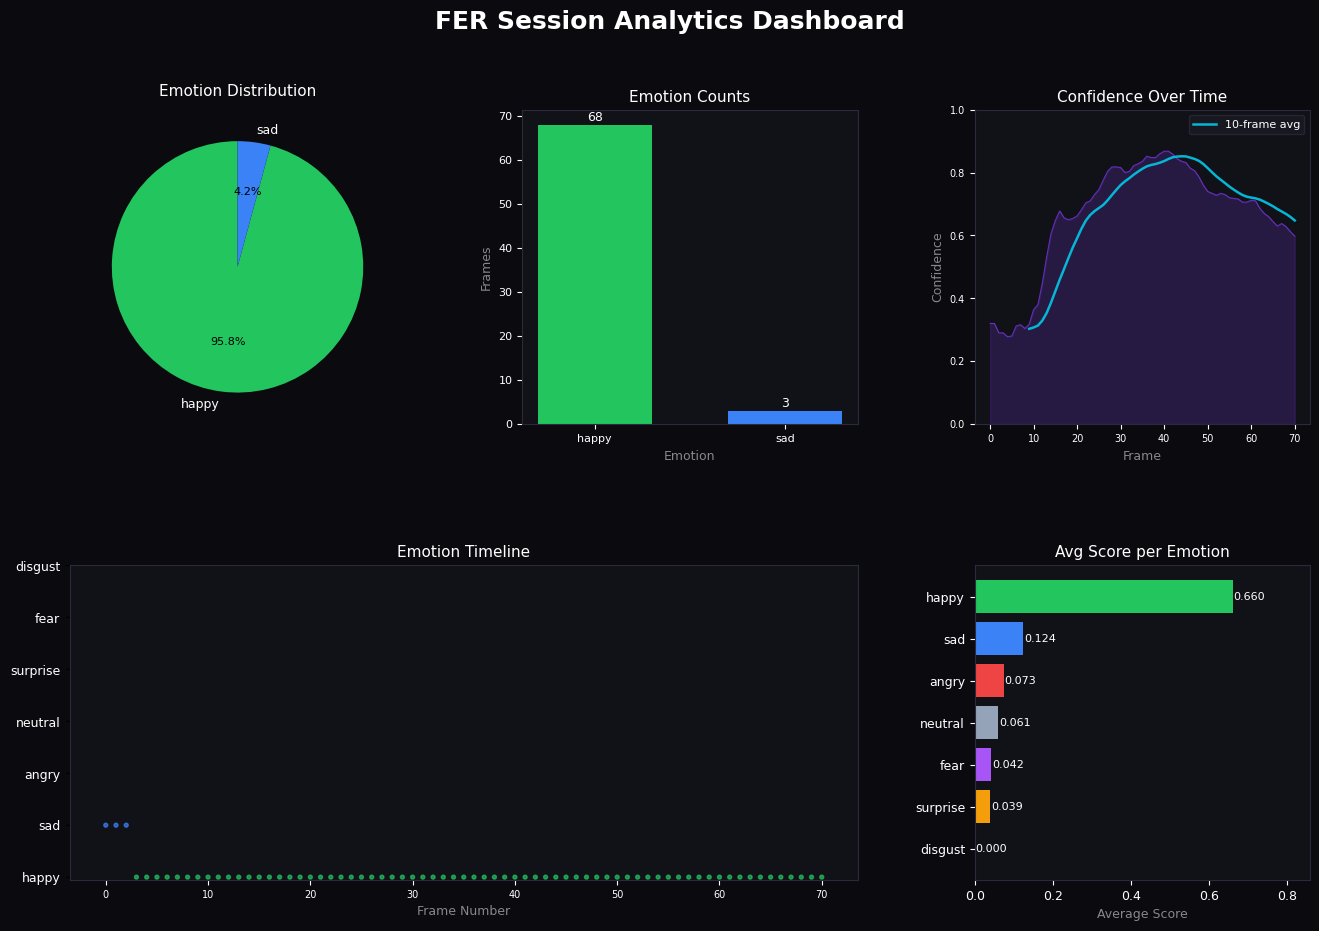

Dashboard saved: logs/analytics_dashboard.png


In [21]:
COLORS = {
    'happy':    '#22c55e',
    'sad':      '#3b82f6',
    'angry':    '#ef4444',
    'neutral':  '#94a3b8',
    'surprise': '#f59e0b',
    'fear':     '#a855f7',
    'disgust':  '#84cc16'
}

fig = plt.figure(figsize=(16, 10), facecolor='#0a0a0f')
fig.suptitle('FER Session Analytics Dashboard',
             fontsize=18, color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Chart 1 - Pie chart
ax1 = fig.add_subplot(gs[0, 0])
counts_data = df['emotion'].value_counts()
pie_colors  = [COLORS.get(e, '#ffffff') for e in counts_data.index]
wedges, texts, autotexts = ax1.pie(
    counts_data.values,
    labels=counts_data.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    textprops={'color': 'white', 'fontsize': 9}
)
for at in autotexts:
    at.set_color('black')
    at.set_fontsize(8)
ax1.set_title('Emotion Distribution', color='white', fontsize=11, pad=10)
ax1.set_facecolor('#0a0a0f')

# Chart 2 - Bar chart
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#111118')
bars = ax2.bar(
    counts_data.index,
    counts_data.values,
    color=[COLORS.get(e, '#fff') for e in counts_data.index],
    edgecolor='none', width=0.6
)
for bar, val in zip(bars, counts_data.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(val), ha='center', va='bottom',
             color='white', fontsize=9)
ax2.set_title('Emotion Counts', color='white', fontsize=11)
ax2.tick_params(colors='white', labelsize=8)
ax2.set_xlabel('Emotion', color='#888', fontsize=9)
ax2.set_ylabel('Frames', color='#888', fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor('#2a2a3a')
fig.patch.set_facecolor('#0a0a0f')
ax2.set_facecolor('#111118')

# Chart 3 - Confidence over time
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#111118')
ax3.plot(df.index, df['confidence'],
         color='#7c3aed', lw=0.8, alpha=0.7)
ax3.fill_between(df.index, df['confidence'],
                 alpha=0.2, color='#7c3aed')
roll = df['confidence'].rolling(10).mean()
ax3.plot(df.index, roll,
         color='#06b6d4', lw=1.8, label='10-frame avg')
ax3.set_title('Confidence Over Time', color='white', fontsize=11)
ax3.tick_params(colors='white', labelsize=7)
ax3.set_xlabel('Frame', color='#888', fontsize=9)
ax3.set_ylabel('Confidence', color='#888', fontsize=9)
ax3.set_ylim(0, 1)
ax3.legend(fontsize=8, labelcolor='white',
           facecolor='#1a1a24', edgecolor='#2a2a3a')
for spine in ax3.spines.values():
    spine.set_edgecolor('#2a2a3a')

# Chart 4 - Emotion timeline
ax4 = fig.add_subplot(gs[1, :2])
ax4.set_facecolor('#111118')
emotion_list = list(COLORS.keys())
df['emo_idx'] = df['emotion'].apply(
    lambda e: emotion_list.index(e) if e in emotion_list else 0
)
scatter_colors = [COLORS.get(e, '#fff') for e in df['emotion']]
ax4.scatter(df.index, df['emo_idx'],
            c=scatter_colors, s=8, alpha=0.7)
ax4.set_yticks(range(len(emotion_list)))
ax4.set_yticklabels(emotion_list, color='white', fontsize=9)
ax4.set_title('Emotion Timeline', color='white', fontsize=11)
ax4.tick_params(axis='x', colors='white', labelsize=7)
ax4.set_xlabel('Frame Number', color='#888', fontsize=9)
for spine in ax4.spines.values():
    spine.set_edgecolor('#2a2a3a')

# Chart 5 - Average scores
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#111118')
emotion_cols = [e for e in COLORS.keys() if e in df.columns]
avg_scores   = df[emotion_cols].mean().sort_values(ascending=True)
bar_colors   = [COLORS.get(e, '#fff') for e in avg_scores.index]
ax5.barh(avg_scores.index, avg_scores.values,
         color=bar_colors, edgecolor='none')
for i, val in enumerate(avg_scores.values):
    ax5.text(val + 0.002, i, f'{val:.3f}',
             va='center', color='white', fontsize=8)
ax5.set_title('Avg Score per Emotion', color='white', fontsize=11)
ax5.tick_params(colors='white', labelsize=9)
ax5.set_xlabel('Average Score', color='#888', fontsize=9)
ax5.set_xlim(0, avg_scores.max() * 1.3)
for spine in ax5.spines.values():
    spine.set_edgecolor('#2a2a3a')

plt.savefig('logs/analytics_dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Dashboard saved: logs/analytics_dashboard.png")